In [1]:
import numpy as np

occupancies_t = np.load('/Users/sarce/Microscopic/occs_test_local.npy')

In [2]:
def periodic_derivative(array):
    N = len(array)
    dx = 1 / N
    output = np.zeros(N, dtype=float)

    for i in range(N):
        output[i] = (array[(i+1) % N] - array[(i-1) % N]) / (2 * dx)

    return output

def periodic_second_derivative_4th(array):
    dx = 1 / len(array)
    return (
        -np.roll(array, 2)
        + 16*np.roll(array, 1)
        - 30*array
        + 16*np.roll(array, -1)
        - np.roll(array, -2)
    ) / (12 * dx**2)

def spectral_filter(rho, cutoff=0.2):
    N = len(rho)
    k = np.fft.fftfreq(N, d=1/N)
    
    rho_hat = np.fft.fft(rho)
    
    # low-pass filter
    mask = np.abs(k) < cutoff * N
    rho_hat_filtered = rho_hat * mask
    
    return np.real(np.fft.ifft(rho_hat_filtered))

def spectral_derivative_filtered(rho, cutoff=0.2):
    N = len(rho)
    k = np.fft.fftfreq(N, d=1/N)
    
    rho_hat = np.fft.fft(rho)
    
    # low-pass filter
    mask = np.abs(k) < cutoff * N
    rho_hat_filtered = rho_hat * mask
    
    return np.real(np.fft.ifft(1j*(2*np.pi*k) * rho_hat_filtered))

def spectral_second_derivative_filtered(rho, cutoff=0.2):
    N = len(rho)
    k = np.fft.fftfreq(N, d=1/N)
    
    rho_hat = np.fft.fft(rho)
    
    # low-pass filter
    mask = np.abs(k) < cutoff * N
    rho_hat_filtered = rho_hat * mask
    
    return np.real(np.fft.ifft(-(2*np.pi*k)**2 * rho_hat_filtered))
# plt.plot(periodic_derivative(meso_avg(occupancies_t[0, 2, :], w)))

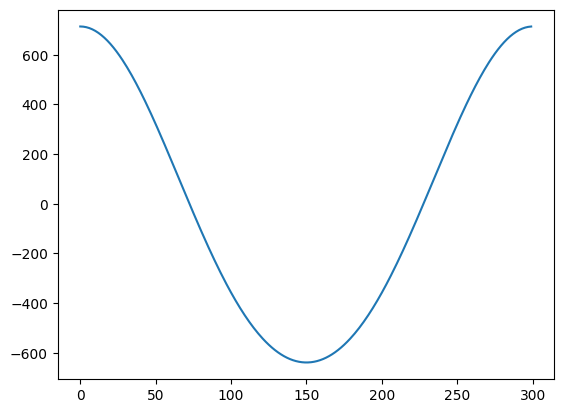

In [7]:
from helper_functions import *
import matplotlib.pyplot as plt

lambd = 3
D = 1

i = 0
w = 0
rho = meso_avg(occupancies_t[i, 0, :], w)
gamma = meso_avg(occupancies_t[i, 2, :], w)

c = 2 / 300
rho_f = spectral_filter(rho, cutoff=c)
gamma_f = spectral_filter(gamma, cutoff=c)
rhox = spectral_derivative_filtered(rho, cutoff=c)
gammax=spectral_derivative_filtered(gamma, cutoff=c)
rhoxx = spectral_second_derivative_filtered(rho, cutoff=c)
gammaxx = spectral_second_derivative_filtered(gamma, cutoff=c)

partialt_rho_dt = 0.05 * ((D + 0.5 * lambd) * rhoxx - lambd / np.sqrt(np.pi) * (rho_f * gammaxx / np.sqrt(gamma_f) + rhox * gammax / np.sqrt(gamma_f) - 0.5 * rho_f * gammax ** 2 / np.sqrt(gamma_f ** 3)))
#partialt_rho -= lambd * periodic_derivative(rho * periodic_derivative(gamma) * T1(gamma)/ gamma)
plt.plot(partialt_rho_dt)

In [8]:
(D + 0.5 * lambd) * rhoxx[0], rho_f[0] * gammaxx[0] / np.sqrt(gamma_f[0]), rhox[0] * gammax[0] / np.sqrt(gamma_f[0]), 0.5 * rho_f[0] * gammax[0] ** 2 / np.sqrt(gamma_f[0] ** 3)

(np.float64(-1470.8703516870994),
 np.float64(-9304.654957862227),
 np.float64(1.201866526153987e-31),
 np.float64(1.0998684513576121e-32))